# Despliegue de modelos de NLP: spam en SMS y sentimiento en tweets

**Autor:** Jheison Martinez Bolivar
**Maestría:** Inteligencia Artificial
**Fecha:** septiembre 2026
**Datasets:** [SMS Spam Collection](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset) y [Twitter Entity Sentiment Analysis](https://www.kaggle.com/datasets/jp797498e/twitter-entity-sentiment-analysis)

---

### Planteamiento del Proyecto

La actividad pide desplegar modelos de machine learning tradicional para dos problemas de clasificación de texto: separar mensajes SMS entre spam y no spam (`spam.csv`), y clasificar el sentimiento de tweets (`twitter_training.csv`). Para cada caso hay que documentar el preprocesamiento, el entrenamiento y la evaluación con métricas claras (precisión, recall, F1), y cerrar con una discusión de fortalezas, debilidades y mejoras posibles.

Trabajo primero el caso de spam, que es binario y pequeño, y después el de sentimiento, que es multiclase y bastante más grande. Las preguntas de investigación de cada caso se fijan después del EDA.


In [1]:
import os
import warnings

warnings.filterwarnings('ignore', module='tqdm')

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_colwidth', 120)

spam_dir = Path(kagglehub.dataset_download('uciml/sms-spam-collection-dataset'))
spam_raw = pd.read_csv(spam_dir / 'spam.csv', encoding='latin-1')

print(f'Ruta: {spam_dir / "spam.csv"}')
print(f'Filas y columnas: {spam_raw.shape}')
print()
print('Nulos por columna:')
print(spam_raw.isna().sum())
print()
print('Filas con algo en las columnas sin nombre:')
display(spam_raw[spam_raw['Unnamed: 2'].notna()].head())


Ruta: /home/jheisonmblivecom/.cache/kagglehub/datasets/uciml/sms-spam-collection-dataset/versions/1/spam.csv
Filas y columnas: (5572, 5)

Nulos por columna:
v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

Filas con algo en las columnas sin nombre:


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
95,spam,"Your free ringtone is waiting to be collected. Simply text the password \MIX\"" to 85069 to verify. Get Usher and Bri...",PO Box 5249,"MK17 92H. 450Ppw 16""",NaN
281,ham,\Wen u miss someone,the person is definitely special for u..... But if the person is so special,why to miss them,"just Keep-in-touch\"" gdeve.."""
444,ham,\HEY HEY WERETHE MONKEESPEOPLE SAY WE MONKEYAROUND! HOWDY GORGEOUS,"HOWU DOIN? FOUNDURSELF A JOBYET SAUSAGE?LOVE JEN XXX\""""",NaN,NaN
671,spam,SMS. ac sun0819 posts HELLO:\You seem cool,"wanted to say hi. HI!!!\"" Stop? Send STOP to 62468""",NaN,NaN
710,ham,Height of Confidence: All the Aeronautics professors wer calld &amp; they wer askd 2 sit in an aeroplane. Aftr they ...,"this wont even start........ Datz confidence..""",NaN,NaN


## Parte 1: spam en SMS

### EDA

El archivo trae cinco columnas pero solo dos con nombre: `v1` es la etiqueta (`ham` = mensaje normal, `spam`) y `v2` el texto. Las otras tres aparecen porque unos pocos mensajes tienen comas sin escapar y el lector los partió: el resto del texto quedó en las columnas de al lado. Si dejo esas filas como están, el modelo vería mensajes truncados; si las elimino pierdo casos válidos. Los reconstruyo pegando los fragmentos y verifico que ya no queden columnas sobrantes.


In [2]:
fragment_cols = ['v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']
split_mask = spam_raw['Unnamed: 2'].notna()

spam = pd.DataFrame({
    'label': spam_raw['v1'],
    'text': (spam_raw[fragment_cols].fillna('').agg(' '.join, axis=1)
             .str.replace(r'\s+', ' ', regex=True).str.replace('å£', '£').str.strip())
})

print(f'Filas reconstruidas: {split_mask.sum()}')
print('Ejemplo antes y despues de reconstruir:')
example_idx = spam_raw.index[split_mask][0]
print(f'  v2 solo : {spam_raw.loc[example_idx, "v2"]!r}')
print(f'  unido   : {spam.loc[example_idx, "text"]!r}')
print()
print('Balance de clases:')
display(spam['label'].value_counts().to_frame('mensajes').assign(proporcion=lambda d: (d['mensajes'] / len(spam)).round(3)))
print(f'Textos duplicados exactos: {spam["text"].duplicated().sum()}')
print('Filas involucradas en duplicados, por clase:')
display(spam[spam['text'].duplicated(keep=False)].groupby('label').size().to_frame('filas_repetidas'))
print('Mensajes mas repetidos:')
display(spam['text'].value_counts().head(8).to_frame('veces'))


Filas reconstruidas: 50
Ejemplo antes y despues de reconstruir:
  v2 solo : 'Your free ringtone is waiting to be collected. Simply text the password \\MIX\\" to 85069 to verify. Get Usher and Britney. FML'
  unido   : 'Your free ringtone is waiting to be collected. Simply text the password \\MIX\\" to 85069 to verify. Get Usher and Britney. FML PO Box 5249 MK17 92H. 450Ppw 16"'

Balance de clases:


,mensajes,proporcion
label,,
ham,4825,0.866
spam,747,0.134


Textos duplicados exactos: 414
Filas involucradas en duplicados, por clase:


,filas_repetidas
label,
ham,503
spam,200


Mensajes mas repetidos:


,veces
text,
"Sorry, I'll call later",30
I cant pick the phone right now. Pls send a message,12
Ok...,10
Please call our customer service representative on FREEPHONE 0808 145 4742 between 9am-11pm as you have WON a guaranteed £1000 cash or £5000 prize!,4
"Wen ur lovable bcums angry wid u, dnt take it seriously.. Coz being angry is d most childish n true way of showing deep affection, care n luv!.. kettoda manda... Have nice day da.",4
Your opinion about me? 1. Over 2. Jada 3. Kusruthi 4. Lovable 5. Silent 6. Spl character 7. Not matured 8. Stylish 9. Simple Pls reply..,4
"7 wonders in My WORLD 7th You 6th Ur style 5th Ur smile 4th Ur Personality 3rd Ur Nature 2nd Ur SMS and 1st \Ur Lovely Friendship\""... good morning dear""",4
"Say this slowly.? GOD,I LOVE YOU &amp; I NEED YOU,CLEAN MY HEART WITH YOUR BLOOD.Send this to Ten special people &amp; u c miracle tomorrow, do it,pls,pls do it...",4


Los duplicados exactos los quito antes de partir train/test. Si el mismo mensaje de premio cae una copia en train y otra en test, el modelo acierta en test porque ya vio ese string idéntico, no porque haya aprendido qué hace que un mensaje sea spam. Es el mismo problema de fuga que voy a encontrar después con las paráfrasis de los tweets, solo que aquí es más obvio porque el texto es exactamente igual. Ojo que la mayoría de los repetidos son ham cortos ("Sorry, I'll call later", "Ok..."), no spam; da igual, la regla aplica a las dos clases.

### P1: ¿qué separa spam de ham antes de entrenar nada?

Antes de vectorizar quiero ver si hay señales superficiales que un modelo de bolsa de palabras ni siquiera necesita: largo del mensaje, cantidad de dígitos, proporción de mayúsculas. Si el spam es sistemáticamente más largo o tiene más números, eso explica parte de lo que los modelos van a "descubrir" y me sirve de línea base para juzgarlos.


Mensajes tras quitar duplicados: 5158


,mensajes
label,
ham,4516
spam,642


Mediana de cada senal superficial por clase:


,chars,words,digits,upper_ratio
label,,,,
ham,53.0,11.0,0.0,0.034
spam,148.0,25.0,16.0,0.098


Proporcion de mensajes con URL o numero de 5+ digitos, por clase:


,proporcion
label,
ham,0.001
spam,0.783


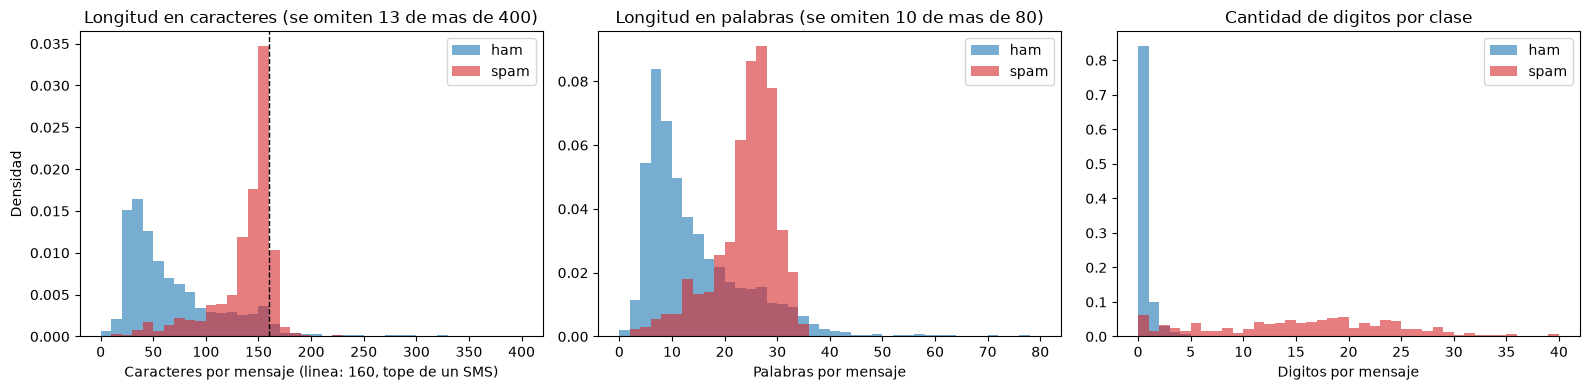

In [3]:
spam = spam.drop_duplicates(subset='text').reset_index(drop=True)
print(f'Mensajes tras quitar duplicados: {len(spam)}')
display(spam['label'].value_counts().to_frame('mensajes'))

surface = pd.DataFrame({
    'label': spam['label'],
    'chars': spam['text'].str.len(),
    'words': spam['text'].str.split().str.len(),
    'digits': spam['text'].str.count(r'\d'),
    'upper_ratio': spam['text'].str.count(r'[A-Z]') / spam['text'].str.len(),
    'has_url_or_phone': spam['text'].str.contains(r'(?:www\.|http|\b\d{5,}\b)', regex=True)
})

print('Mediana de cada senal superficial por clase:')
display(surface.groupby('label')[['chars', 'words', 'digits', 'upper_ratio']].median().round(3))
print('Proporcion de mensajes con URL o numero de 5+ digitos, por clase:')
display(surface.groupby('label')['has_url_or_phone'].mean().round(3).to_frame('proporcion'))

long_messages = (surface['words'] > 80).sum()
long_chars = (surface['chars'] > 400).sum()
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for label, color in [('ham', 'tab:blue'), ('spam', 'tab:red')]:
    subset = surface[surface['label'] == label]
    axes[0].hist(subset['chars'], bins=range(0, 405, 10), alpha=0.6, label=label, color=color, density=True)
    axes[1].hist(subset['words'], bins=range(0, 82, 2), alpha=0.6, label=label, color=color, density=True)
    axes[2].hist(subset['digits'], bins=range(0, 41), alpha=0.6, label=label, color=color, density=True)
axes[0].axvline(160, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Caracteres por mensaje (linea: 160, tope de un SMS)')
axes[0].set_ylabel('Densidad')
axes[0].set_title(f'Longitud en caracteres (se omiten {long_chars} de mas de 400)')
axes[0].legend()
axes[1].set_xlabel('Palabras por mensaje')
axes[1].set_title(f'Longitud en palabras (se omiten {long_messages} de mas de 80)')
axes[1].legend()
axes[2].set_xlabel('Digitos por mensaje')
axes[2].set_title('Cantidad de digitos por clase')
axes[2].legend()
plt.tight_layout()
plt.show()


El spam es más largo y se apila justo debajo de los 160 caracteres que caben en un SMS (el pico rojo pegado a la línea del primer histograma), mientras el ham se concentra en mensajes cortos con una cola larga. Y casi siempre trae un número largo o una URL; el ham casi nunca. Eso me deja dos consecuencias para lo que sigue.

Primera: la accuracy no sirve como métrica principal. Con siete de cada ocho mensajes siendo ham, un modelo que diga "todo es ham" ya queda por encima del 85 % sin detectar nada. Me tengo que fijar en precision y recall de la clase spam, y en su F1 como resumen.

Segunda: los modelos tienen que ganarle a algo. Antes de vectorizar mido dos líneas base sobre el mismo test que van a usar los modelos: predecir siempre ham, y la regla "tiene URL o un número de 5+ dígitos → spam". Parto train/test estratificado (80/20) para que la proporción de spam sea la misma en los dos lados.



In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support, classification_report, confusion_matrix, ConfusionMatrixDisplay

X_train, X_test, y_train, y_test = train_test_split(
    spam['text'], spam['label'], test_size=0.2, stratify=spam['label'], random_state=42
)
print(f'Train: {len(X_train)} mensajes, test: {len(X_test)} mensajes')
print(f'Proporcion de spam en test: {(y_test == "spam").mean():.3f}')

rule_pred = np.where(X_test.str.contains(r'(?:www\.|http|\b\d{5,}\b)', regex=True), 'spam', 'ham')
majority_pred = np.full(len(y_test), 'ham')

def summarize(y_true, y_pred, name):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, pos_label='spam', average='binary', zero_division=0)
    return {'modelo': name, 'accuracy': (y_true == y_pred).mean(), 'precision_spam': p, 'recall_spam': r, 'f1_spam': f}

baselines = pd.DataFrame([
    summarize(y_test, majority_pred, 'siempre ham'),
    summarize(y_test, rule_pred, 'regla: URL o numero largo')
]).set_index('modelo').round(3)
print('Lineas base en test:')
display(baselines)


Train: 4126 mensajes, test: 1032 mensajes
Proporcion de spam en test: 0.124
Lineas base en test:


,accuracy,precision_spam,recall_spam,f1_spam
modelo,,,,
siempre ham,0.876,0.0,0.000,0.000
regla: URL o numero largo,0.976,1.0,0.805,0.892


La regla tonta no tiene falsos positivos y atrapa cuatro de cada cinco spam: F1 de 0.89 sin ningún modelo. Ese es el listón. Un modelo de TF-IDF que quede por debajo no aporta nada que una expresión regular no haga; lo que espero que compre es el quinto spam que la regla se pierde (los que no traen número ni URL) sin empezar a marcar ham.

### P2: ¿cuál de los tres modelos lineales sobre TF-IDF le gana a la regla, y en qué?

Represento cada mensaje con TF-IDF de unigramas y bigramas en minúsculas. Los tres clasificadores son lineales sobre ese mismo vector, así que la comparación aísla *cómo* aprenden los pesos: Naive Bayes multinomial cuenta frecuencias por clase asumiendo independencia entre términos; la regresión logística ajusta los pesos maximizando la verosimilitud; LinearSVC busca el margen máximo entre clases. Selecciono con validación cruzada estratificada de 5 pliegues sobre el train y solo después miro el test. Como la regla la medí en test y los modelos van en validación cruzada sobre train, no son el mismo conjunto: para que la comparación sea justa imprimo también la regla sobre el train.



In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate

def make_pipeline(model, ngram_range=(1, 2)):
    return Pipeline([
        ('tfidf', TfidfVectorizer(lowercase=True, ngram_range=ngram_range, min_df=2, sublinear_tf=True)),
        ('clf', model)
    ])

candidates = {
    'MultinomialNB': MultinomialNB(),
    'LogisticRegression': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'LinearSVC': LinearSVC(class_weight='balanced')
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'precision_spam': 'precision', 'recall_spam': 'recall', 'f1_spam': 'f1'}

def cv_table(pipelines, X, y, cv, scoring, pos_label='spam'):
    rows = []
    for name, pipe in pipelines.items():
        scores = cross_validate(pipe, X, y == pos_label, cv=cv, scoring=scoring)
        row = {'modelo': name}
        for metric in scoring:
            row[metric] = scores[f'test_{metric}'].mean()
            row[f'{metric}_std'] = scores[f'test_{metric}'].std()
        rows.append(row)
    return pd.DataFrame(rows).set_index('modelo').round(3)

spam_cv = cv_table({name: make_pipeline(model) for name, model in candidates.items()}, X_train, y_train, cv, scoring)
print('Validacion cruzada (5 pliegues) sobre train, clase positiva = spam:')
display(spam_cv)


rule_train_pred = np.where(X_train.str.contains(r'(?:www\.|http|\b\d{5,}\b)', regex=True), 'spam', 'ham')
rule_train = pd.DataFrame([summarize(y_train.to_numpy(), rule_train_pred, 'regla: URL o numero largo')]).set_index('modelo').round(3)
print('La misma regla sobre el train completo, para compararla con la validacion cruzada:')
display(rule_train[['precision_spam', 'recall_spam', 'f1_spam']])


Validacion cruzada (5 pliegues) sobre train, clase positiva = spam:


,precision_spam,precision_spam_std,recall_spam,recall_spam_std,f1_spam,f1_spam_std
modelo,,,,,,
MultinomialNB,1.000,0.000,0.671,0.036,0.803,0.025
LogisticRegression,0.922,0.017,0.934,0.019,0.928,0.011
LinearSVC,0.967,0.011,0.916,0.027,0.941,0.012


La misma regla sobre el train completo, para compararla con la validacion cruzada:


,precision_spam,recall_spam,f1_spam
modelo,,,
regla: URL o numero largo,0.99,0.778,0.871


Regresión logística y LinearSVC le ganan a la regla; Naive Bayes no. Tiene precisión perfecta pero se le escapa un tercio del spam, peor que la expresión regular.

#### P2.1: ¿por qué Naive Bayes sale tan conservador?

Mi hipótesis: el prior. NB arranca de la proporción de cada clase, y con siete de cada ocho mensajes siendo ham, ese prior aplasta la evidencia de las palabras salvo que sean señales fortísimas. Los otros dos modelos llevan `class_weight='balanced'` y no sufren eso. Si tengo razón, forzar un prior uniforme (`fit_prior=False`) debería subir el recall. Pero hay un segundo sospechoso que quiero medir al lado: el suavizado. `alpha=1` suma un pseudo-conteo de 1 a cada término, y con TF-IDF los valores reales son fracciones pequeñas, así que ese 1 puede pesar más que los datos. Pruebo las dos cosas por separado y juntas, y también NB sobre conteos crudos, que es como se suele usar.



In [6]:
from sklearn.feature_extraction.text import CountVectorizer

nb_variants = {
    'NB tfidf, alpha=1 (base)': make_pipeline(MultinomialNB()),
    'NB tfidf, prior uniforme': make_pipeline(MultinomialNB(fit_prior=False)),
    'NB tfidf, alpha=0.1': make_pipeline(MultinomialNB(alpha=0.1)),
    'NB tfidf, alpha=0.1 + prior uniforme': make_pipeline(MultinomialNB(alpha=0.1, fit_prior=False)),
    'NB conteos, alpha=1': Pipeline([('counts', CountVectorizer(ngram_range=(1, 2), min_df=2)), ('clf', MultinomialNB())]),
}
nb_cv = cv_table(nb_variants, X_train, y_train, cv, scoring)
print('Variantes de Naive Bayes, validacion cruzada sobre train:')
display(nb_cv[['precision_spam', 'recall_spam', 'f1_spam', 'f1_spam_std']])


Variantes de Naive Bayes, validacion cruzada sobre train:


,precision_spam,recall_spam,f1_spam,f1_spam_std
modelo,,,,
"NB tfidf, alpha=1 (base)",1.000,0.671,0.803,0.025
"NB tfidf, prior uniforme",0.958,0.883,0.919,0.023
"NB tfidf, alpha=0.1",0.991,0.887,0.936,0.013
"NB tfidf, alpha=0.1 + prior uniforme",0.888,0.942,0.914,0.004
"NB conteos, alpha=1",0.967,0.905,0.935,0.008


Mi hipótesis del prior se sostiene a medias: forzar un prior uniforme sube el recall, y bajar el suavizado lo sube prácticamente igual; la diferencia entre las dos está en la precisión, que con `alpha=0.1` casi no se pierde y con el prior uniforme sí. Las dos cosas juntas se pasan de rosca: más recall todavía, pero la precisión cae por debajo de la de los otros modelos. Con conteos crudos NB anda bien sin tocar nada. El problema no era Naive Bayes sino Naive Bayes sobre TF-IDF con `alpha=1`, que es la combinación que puse por defecto sin pensar. No aíslo más allá de eso: la tabla muestra que ocurre y qué lo corrige, no derivo el mecanismo exacto.

#### P2.2: ¿los bigramas aportan algo?

Antes de ir al test quiero saber si el "contexto" de los n-gramas vale lo que cuesta. Mi apuesta: los bigramas suben poco, del orden de una centésima, porque palabras como "prize" o "claim" ya son señal sueltas y el bigrama solo refuerza. Lo mido con la misma validación cruzada, nunca sobre el test: el test se toca una sola vez, con la configuración ya elegida, si no la métrica final deja de ser honesta. De paso pruebo trigramas y n-gramas de caracteres, que capturan cosas como "£1000", "txt" o números de teléfono sin depender de dónde caen los espacios.




In [7]:
feature_configs = {
    'unigramas': dict(ngram_range=(1, 1)),
    'uni+bigramas': dict(ngram_range=(1, 2)),
    'uni+bi+trigramas': dict(ngram_range=(1, 3)),
    'caracteres 2-5': dict(analyzer='char_wb', ngram_range=(2, 5)),
}
selected_models = {
    'MultinomialNB(alpha=0.1)': lambda: MultinomialNB(alpha=0.1),
    'LogisticRegression': lambda: LogisticRegression(max_iter=2000, class_weight='balanced'),
    'LinearSVC': lambda: LinearSVC(class_weight='balanced'),
}
rows = []
for feat_name, feat_kwargs in feature_configs.items():
    for model_name, make_model in selected_models.items():
        pipe = Pipeline([
            ('tfidf', TfidfVectorizer(lowercase=True, min_df=2, sublinear_tf=True, **feat_kwargs)),
            ('clf', make_model())
        ])
        scores = cross_validate(pipe, X_train, y_train == 'spam', cv=cv, scoring=scoring)
        rows.append({'caracteristicas': feat_name, 'modelo': model_name,
                     'precision_spam': scores['test_precision_spam'].mean(),
                     'recall_spam': scores['test_recall_spam'].mean(),
                     'f1_spam': scores['test_f1_spam'].mean(),
                     'f1_spam_std': scores['test_f1_spam'].std()})
ngram_cv = pd.DataFrame(rows).round(3)
print('F1 de spam en validacion cruzada segun las caracteristicas:')
display(ngram_cv.pivot(index='caracteristicas', columns='modelo', values='f1_spam').loc[list(feature_configs)])
print('Detalle completo:')
display(ngram_cv.set_index(['caracteristicas', 'modelo']))


F1 de spam en validacion cruzada segun las caracteristicas:


modelo,LinearSVC,LogisticRegression,MultinomialNB(alpha=0.1)
caracteristicas,,,
unigramas,0.931,0.914,0.925
uni+bigramas,0.941,0.928,0.936
uni+bi+trigramas,0.940,0.924,0.929
caracteres 2-5,0.959,0.960,0.950


Detalle completo:


precision_spam  recall_spam  \
caracteristicas  modelo                                                  
unigramas        MultinomialNB(alpha=0.1)           0.987        0.872   
                 LogisticRegression                 0.902        0.926   
                 LinearSVC                          0.956        0.909   
uni+bigramas     MultinomialNB(alpha=0.1)           0.991        0.887   
                 LogisticRegression                 0.922        0.934   
                 LinearSVC                          0.967        0.916   
uni+bi+trigramas MultinomialNB(alpha=0.1)           0.996        0.872   
                 LogisticRegression                 0.917        0.932   
                 LinearSVC                          0.963        0.918   
caracteres 2-5   MultinomialNB(alpha=0.1)           0.976        0.926   
                 LogisticRegression                 0.980        0.942   
                 LinearSVC                          0.988        0.932   

                                           f1_spam  f1_spam_std  
caracteristicas  modelo                                          
unigramas        MultinomialNB(alpha=0.1)    0.925        0.015  
                 LogisticRegression          0.914        0.013  
                 LinearSVC                   0.931        0.015  
uni+bigramas     MultinomialNB(alpha=0.1)    0.936        0.013  
                 LogisticRegression          0.928        0.011  
                 LinearSVC                   0.941        0.012  
uni+bi+trigramas MultinomialNB(alpha=0.1)    0.929        0.015  
                 LogisticRegression          0.924        0.014  
                 LinearSVC                   0.940        0.013  
caracteres 2-5   MultinomialNB(alpha=0.1)    0.950        0.013  
                 LogisticRegression          0.960        0.007  
                 LinearSVC                   0.959        0.012

Los bigramas suben una centésima, como aposté, y los trigramas ya no suman. Lo que no esperaba es que los n-gramas de caracteres le ganen a todas las configuraciones de palabras con los tres modelos. Tiene sentido a posteriori: en un SMS la señal está en pedazos como "£", "txt", "claim", "www." o secuencias de dígitos, y los caracteres los capturan aunque vengan pegados a otra cosa o mal escritos, que en spam es lo normal.

Con caracteres, regresión logística y LinearSVC empatan dentro del ruido entre pliegues. Para desempatar no uso la milésima de F1 sino lo que necesita el modelo desplegado: cuando alguien le pase un mensaje, quiero devolver una probabilidad ("spam con 0.97") y no solo una etiqueta. La regresión logística la da directamente con `predict_proba`; LinearSVC solo da un score sin escala. Me quedo con **regresión logística sobre TF-IDF de caracteres 2-5**.

#### Evaluación en test

Ahora sí, una sola vez: entreno la configuración elegida con todo el train y la evalúo sobre los mensajes que ningún paso anterior tocó. Además del reporte por clase quiero ver los errores uno por uno con su probabilidad, porque siete números de una tabla no me dicen *qué* se le escapa al modelo.



Caracteristicas (n-gramas de caracteres) en el vocabulario: 32639

Reporte de clasificacion en test:
              precision    recall  f1-score   support

         ham      0.994     0.998     0.996       904
        spam      0.984     0.961     0.972       128

    accuracy                          0.993      1032
   macro avg      0.989     0.979     0.984      1032
weighted avg      0.993     0.993     0.993      1032

Modelo final frente a las lineas base, mismo test:


,accuracy,precision_spam,recall_spam,f1_spam
modelo,,,,
siempre ham,0.876,0.000,0.000,0.000
regla: URL o numero largo,0.976,1.000,0.805,0.892
LogReg + TF-IDF caracteres,0.993,0.984,0.961,0.972


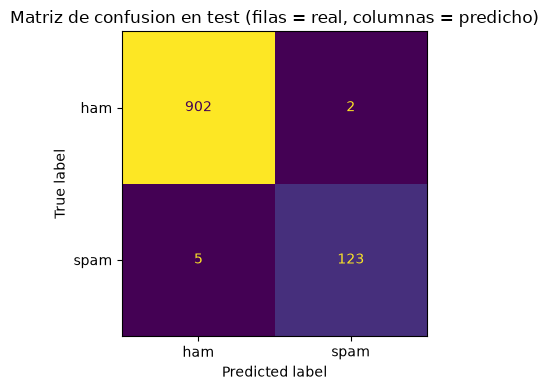

Errores en test: 7 de 1032


,text,real,predicho,p_spam
3171,Sorry I missed your call let's talk when you have the time. I'm on 07090201529,spam,ham,0.205
4604,"Hi this is Amy, we will be sending you a free phone number in a couple of days, which will give you an access to all...",spam,ham,0.207
4978,dating:i have had two of these. Only started after i sent a text to talk sport radio last week. Any connection do yo...,spam,ham,0.364
2325,Guess who am I?This is the first time I created a web page WWW.ASJESUS.COM read all I wrote. I'm waiting for your op...,spam,ham,0.418
2298,Babe: U want me dont u baby! Im nasty and have a thing 4 filthyguys. Fancy a rude time with a sexy bitch. How about ...,spam,ham,0.425
177,Hi! You just spoke to MANEESHA V. We'd like to know if you were satisfied with the experience. Reply Toll Free with ...,ham,spam,0.507
562,Waiting for your call.,ham,spam,0.556


In [8]:
spam_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(lowercase=True, analyzer='char_wb', ngram_range=(2, 5), min_df=2, sublinear_tf=True)),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))
]).fit(X_train, y_train)

spam_pred = spam_pipeline.predict(X_test)
spam_proba = spam_pipeline.predict_proba(X_test)[:, list(spam_pipeline.classes_).index('spam')]

print(f'Caracteristicas (n-gramas de caracteres) en el vocabulario: {len(spam_pipeline.named_steps["tfidf"].vocabulary_)}')
print()
print('Reporte de clasificacion en test:')
print(classification_report(y_test, spam_pred, digits=3))

comparison = pd.concat([baselines, pd.DataFrame([summarize(y_test, spam_pred, 'LogReg + TF-IDF caracteres')]).set_index('modelo').round(3)])
print('Modelo final frente a las lineas base, mismo test:')
display(comparison)

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, spam_pred, labels=['ham', 'spam']), display_labels=['ham', 'spam']).plot(ax=ax, colorbar=False)
ax.set_title('Matriz de confusion en test (filas = real, columnas = predicho)')
plt.tight_layout()
plt.show()

errors = pd.DataFrame({'text': X_test, 'real': y_test, 'predicho': spam_pred, 'p_spam': spam_proba.round(3)})
errors = errors[errors['real'] != errors['predicho']].sort_values('p_spam')
print(f'Errores en test: {len(errors)} de {len(X_test)}')
display(errors)


Siete errores en mil mensajes. Los cinco spam que se escapan son spam "suave": están escritos como conversación personal ("Sorry I missed your call", "Hi this is Amy", "dating: i have had two of these"). Dos de los cinco sí traen una marca de P1 (una URL en mayúsculas, un número de once dígitos) y aun así el tono del resto del mensaje pesa más; dos de ellos salen con probabilidad claramente baja y los otros tres quedan entre 0.36 y 0.43, o sea cerca del umbral: el modelo duda, pero se inclina a ham. Los dos ham marcados como spam están justo al borde (0.51 y 0.56): una encuesta de satisfacción con "Reply Toll Free" y un "Waiting for your call" que suena a spam sin serlo.

Para un filtro en el teléfono de una persona, el falso positivo es el error caro: un mensaje legítimo que desaparece. El spam que se cuela, molesta pero se ve y se borra. Eso me lleva a pensar en subir el umbral por encima de 0.5. Pero no lo puedo elegir mirando el test, que ya usé; lo elijo con las probabilidades fuera-de-pliegue del train (`cross_val_predict`) y después reporto qué habría pasado en test con ese umbral, como consecuencia y no como ajuste.




In [9]:
from sklearn.model_selection import cross_val_predict

oof_proba = cross_val_predict(spam_pipeline, X_train, y_train, cv=cv, method='predict_proba')[:, list(spam_pipeline.classes_).index('spam')]

def threshold_table(y_true, proba, thresholds):
    rows = []
    for t in thresholds:
        pred = np.where(proba >= t, 'spam', 'ham')
        row = summarize(y_true, pred, f'{t:.2f}')
        row['falsos_positivos'] = int(((pred == 'spam') & (y_true == 'ham')).sum())
        row['falsos_negativos'] = int(((pred == 'ham') & (y_true == 'spam')).sum())
        rows.append(row)
    return pd.DataFrame(rows).rename(columns={'modelo': 'umbral'}).set_index('umbral').round(3)

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
print('Umbral sobre las probabilidades fuera-de-pliegue del train:')
display(threshold_table(y_train.to_numpy(), oof_proba, thresholds))
print('Consecuencia de cada umbral en test (no se usa para elegir):')
display(threshold_table(y_test.to_numpy(), spam_proba, thresholds))


Umbral sobre las probabilidades fuera-de-pliegue del train:


,accuracy,precision_spam,recall_spam,f1_spam,falsos_positivos,falsos_negativos
umbral,,,,,,
0.30,0.975,0.853,0.969,0.907,86,16
0.40,0.988,0.948,0.953,0.951,27,24
0.50,0.990,0.980,0.942,0.960,10,30
0.60,0.988,0.992,0.911,0.949,4,46
0.70,0.984,0.998,0.875,0.933,1,64
0.80,0.974,1.000,0.788,0.881,0,109
0.90,0.949,1.000,0.591,0.743,0,210


Consecuencia de cada umbral en test (no se usa para elegir):


,accuracy,precision_spam,recall_spam,f1_spam,falsos_positivos,falsos_negativos
umbral,,,,,,
0.30,0.986,0.913,0.984,0.947,12,2
0.40,0.994,0.977,0.977,0.977,3,3
0.50,0.993,0.984,0.961,0.972,2,5
0.60,0.988,1.000,0.906,0.951,0,12
0.70,0.985,1.000,0.883,0.938,0,15
0.80,0.981,1.000,0.844,0.915,0,20
0.90,0.958,1.000,0.664,0.798,0,43


La tabla del train dice lo que cuesta cada falso positivo evitado: pasar de 0.5 a 0.6 quita seis falsos positivos y añade dieciséis falsos negativos; en test el patrón es el mismo, cero ham perdidos a cambio de más del doble de spam colado. No hay umbral que sea gratis. Para el modelo desplegado dejo la etiqueta en 0.5, que es donde el F1 es máximo, y muestro siempre la probabilidad: quien la use puede leer un 0.55 como "dudoso" en vez de como "spam", que es lo que el umbral fijo esconde.

Cierro el caso spam con lo que quedó medido: la representación importó más que el clasificador (caracteres vs palabras movió más el F1 que cambiar de modelo), Naive Bayes solo falló por combinarlo con TF-IDF sin ajustar el suavizado, y el error residual es spam escrito como conversación, que las señales superficiales de P1 solo atrapan a medias. El límite del resultado: el corpus es de SMS en inglés de hace más de una década; nada aquí dice cómo se comporta con mensajes de WhatsApp actuales o en español.

---

## Parte 2: sentimiento en tweets

### EDA

El segundo dataset trae tweets etiquetados con cuatro sentimientos respecto a una entidad (una marca, un juego, una empresa): `Positive`, `Negative`, `Neutral` e `Irrelevant`, esta última para tweets que mencionan la entidad pero no hablan de ella. Viene en dos archivos, `twitter_training.csv` y `twitter_validation.csv`, sin encabezado; las columnas son id del tweet, entidad, sentimiento y texto. Empiezo por ver qué hay antes de decidir cómo lo parto.




In [10]:
tweets_dir = Path(kagglehub.dataset_download('jp797498e/twitter-entity-sentiment-analysis'))
tweet_cols = ['tweet_id', 'entity', 'sentiment', 'text']
tweets_raw = pd.read_csv(tweets_dir / 'twitter_training.csv', header=None, names=tweet_cols)
tweets_val_raw = pd.read_csv(tweets_dir / 'twitter_validation.csv', header=None, names=tweet_cols)

print(f'Train: {tweets_raw.shape}, validation: {tweets_val_raw.shape}')
print()
print('Nulos por columna (train):')
print(tweets_raw.isna().sum())
print()
print('Balance de clases (train):')
display(tweets_raw['sentiment'].value_counts().to_frame('tweets').assign(proporcion=lambda d: (d['tweets'] / len(tweets_raw)).round(3)))
print(f'Entidades distintas: {tweets_raw["entity"].nunique()}')
print(f'Ids de tweet distintos: {tweets_raw["tweet_id"].nunique()} para {len(tweets_raw)} filas')
print('Filas por id de tweet:')
display(tweets_raw.groupby('tweet_id').size().value_counts().to_frame('ids'))
print('Sentimientos distintos dentro de un mismo id:')
display(tweets_raw.groupby('tweet_id')['sentiment'].nunique().value_counts().to_frame('ids'))
print('Entidades distintas dentro de un mismo id:')
display(tweets_raw.groupby('tweet_id')['entity'].nunique().value_counts().to_frame('ids'))
print('Un id completo, para ver que son las seis filas:')
display(tweets_raw[tweets_raw['tweet_id'] == 2401])



Train: (74682, 4), validation: (1000, 4)

Nulos por columna (train):
tweet_id       0
entity         0
sentiment      0
text         686
dtype: int64

Balance de clases (train):


,tweets,proporcion
sentiment,,
Negative,22542,0.302
Positive,20832,0.279
Neutral,18318,0.245
Irrelevant,12990,0.174


Entidades distintas: 32
Ids de tweet distintos: 12447 para 74682 filas
Filas por id de tweet:


,ids
6,12447


Sentimientos distintos dentro de un mismo id:


,ids
sentiment,
1,12447


Entidades distintas dentro de un mismo id:


,ids
entity,
1,12447


Un id completo, para ver que son las seis filas:


,tweet_id,entity,sentiment,text
0,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
1,2401,Borderlands,Positive,"I am coming to the borders and I will kill you all,"
2,2401,Borderlands,Positive,"im getting on borderlands and i will kill you all,"
3,2401,Borderlands,Positive,"im coming on borderlands and i will murder you all,"
4,2401,Borderlands,Positive,"im getting on borderlands 2 and i will murder you me all,"
5,2401,Borderlands,Positive,"im getting into borderlands and i can murder you all,"


Cada id aparece exactamente seis veces, siempre con el mismo sentimiento y la misma entidad, y las seis filas son el mismo tweet reescrito: sinónimos, cambios de orden, alguna palabra rota y tokens como `[UNK]` que delatan un modelo automático. No son seis tweets, es un tweet con cinco paráfrasis generadas por el autor del dataset como aumento de datos. Eso cambia cómo hay que partir train/test, pero antes quiero medir tres cosas más: duplicados exactos, textos con etiqueta contradictoria, y si el `validation.csv` que viene aparte es independiente del train o no.


In [11]:
tweets = tweets_raw.dropna(subset=['text']).copy()
tweets = tweets[tweets['text'].str.strip() != '']

exact_dupes = tweets['text'].duplicated(keep=False)
label_conflict = tweets.groupby('text')['sentiment'].transform('nunique') > 1
print(f'Filas con texto no vacio: {len(tweets)}')
print(f'Filas con texto exactamente repetido: {exact_dupes.sum()}')
print(f'Filas cuyo texto aparece con mas de un sentimiento: {label_conflict.sum()}')
print(f'Textos distintos con etiqueta contradictoria: {tweets.loc[label_conflict, "text"].nunique()}')
conflict_texts = (tweets[label_conflict].groupby('text')
                  .agg(filas=('sentiment', 'size'), sentimientos=('sentiment', 'nunique'), palabras=('text', lambda s: len(s.iloc[0].split())))
                  .sort_values('filas', ascending=False))
print('Los textos contradictorios mas repetidos (texto recortado a 90 caracteres):')
conflict_view = conflict_texts.head(10).copy()
conflict_view.index = [t[:90] for t in conflict_view.index]
display(conflict_view)
print('Cuantas de esas filas tienen 1, 2, 3+ palabras:')
display(tweets.loc[label_conflict, 'text'].str.split().str.len().clip(upper=3).value_counts().sort_index().rename(index={3: '3+'}).to_frame('filas'))

val_ids_in_train = tweets_val_raw['tweet_id'].isin(tweets_raw['tweet_id'])
val_text_in_train = tweets_val_raw['text'].isin(tweets_raw['text'])
print()
print('Relacion entre validation.csv y train:')
display(pd.DataFrame({
    'tweets de validation': [len(tweets_val_raw)],
    'con id presente en train': [int(val_ids_in_train.sum())],
    'con texto identico en train': [int(val_text_in_train.sum())]
}))
print('Sentimiento por entidad (proporcion por fila), entidades ordenadas por su proporcion de Irrelevant:')
entity_sentiment = pd.crosstab(tweets['entity'], tweets['sentiment'], normalize='index').round(2)
display(entity_sentiment.sort_values('Irrelevant', ascending=False))



Filas con texto no vacio: 73824
Filas con texto exactamente repetido: 6462
Filas cuyo texto aparece con mas de un sentimiento: 1948
Textos distintos con etiqueta contradictoria: 136
Los textos contradictorios mas repetidos (texto recortado a 90 caracteres):


,filas,sentimientos,palabras
It is not the first time that the EU Commission has taken such a step.,172,4,15
"At the same time, despite the fact that there are currently some 100 million people living",172,4,49
<unk>,133,4,1
to,74,4,1
I,72,4,1
the,68,4,1
you,63,4,1
of,57,4,1
a,53,4,1
is,46,4,1


Cuantas de esas filas tienen 1, 2, 3+ palabras:


,filas
text,
1,1455
2,49
3+,444



Relacion entre validation.csv y train:


,tweets de validation,con id presente en train,con texto identico en train
0,1000,1000,517


Sentimiento por entidad (proporcion por fila), entidades ordenadas por su proporcion de Irrelevant:


sentiment,Irrelevant,Negative,Neutral,Positive
entity,,,,
Battlefield,0.40,0.20,0.15,0.25
PlayerUnknownsBattlegrounds(PUBG),0.40,0.30,0.12,0.18
Fortnite,0.37,0.31,0.07,0.25
GrandTheftAuto(GTA),0.33,0.26,0.14,0.27
Xbox(Xseries),0.31,0.16,0.18,0.35
Overwatch,0.29,0.27,0.13,0.31
Facebook,0.29,0.30,0.33,0.07
CallOfDuty,0.28,0.37,0.16,0.19
CS-GO,0.28,0.15,0.24,0.33


Tres hallazgos que condicionan todo lo que sigue. Primero, el `validation.csv` no es un conjunto independiente: todos sus ids están en el train y la mitad de sus textos son idénticos a filas del train, así que no lo puedo usar como test limpio. Segundo, los textos con etiqueta contradictoria son muchas filas pero muy pocos textos distintos, y la tabla de los más repetidos muestra qué son: basura del generador de paráfrasis. Tres de cada cuatro filas son una sola palabra (`<unk>`, `to`, `I`, `the`) y los dos textos más frecuentes son frases de prensa que no tienen nada que ver con ninguna entidad y aparecen con las cuatro etiquetas. Tercero, la entidad tiene una relación clara con el sentimiento (hay juegos con mayoría positiva y marcas con mayoría neutral), algo que anoto para más adelante.

Limpio lo acordado: filas sin texto, textos con etiqueta contradictoria y duplicados exactos. Sobre los textos de dos palabras o menos que quedan, no los quito por intuición: en P4 mido si entrenar sin ellos cambia algo.

### P3: ¿cuánto infla la métrica repartir las paráfrasis entre train y test?

Si las seis variantes de un tweet se reparten al azar, el modelo ve en test frases casi idénticas a las que memorizó en train. Mi apuesta es que la métrica sale muy inflada. Lo mido con un mismo modelo (LinearSVC sobre TF-IDF de unigramas y bigramas) y dos formas de partir: aleatoria estratificada, y por id de tweet con `GroupShuffleSplit`, que manda las seis variantes al mismo lado. La métrica principal en cuatro clases es el F1 macro: promedio del F1 de cada clase sin ponderar por tamaño, para que Irrelevant, la minoritaria, cuente igual que las demás.



In [12]:
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import f1_score

tweets = tweets[~label_conflict.loc[tweets.index]].drop_duplicates(subset='text').reset_index(drop=True)
tweets['words'] = tweets['text'].str.split().str.len()
print(f'Tweets tras limpiar: {len(tweets)} filas, {tweets["tweet_id"].nunique()} ids')
display(tweets['sentiment'].value_counts().to_frame('tweets'))

def tweet_pipeline(model, **tfidf_kwargs):
    kwargs = dict(lowercase=True, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
    kwargs.update(tfidf_kwargs)
    return Pipeline([('tfidf', TfidfVectorizer(**kwargs)), ('clf', model)])

def evaluate_split(train_idx, test_idx, model):
    pipe = tweet_pipeline(model).fit(tweets.loc[train_idx, 'text'], tweets.loc[train_idx, 'sentiment'])
    pred = pipe.predict(tweets.loc[test_idx, 'text'])
    truth = tweets.loc[test_idx, 'sentiment']
    shared_ids = tweets.loc[test_idx, 'tweet_id'].isin(tweets.loc[train_idx, 'tweet_id']).mean()
    return {'f1_macro': f1_score(truth, pred, average='macro'), 'accuracy': (pred == truth).mean(),
            'test_ids_tambien_en_train': shared_ids}

random_train, random_test = train_test_split(tweets.index, test_size=0.2, stratify=tweets['sentiment'], random_state=42)
group_splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
group_train_pos, group_test_pos = next(group_splitter.split(tweets, groups=tweets['tweet_id']))
group_train, group_test = tweets.index[group_train_pos], tweets.index[group_test_pos]

leak_table = pd.DataFrame({
    'split aleatorio': evaluate_split(random_train, random_test, LinearSVC()),
    'split por id de tweet': evaluate_split(group_train, group_test, LinearSVC()),
}).T.round(3)
print('Mismo modelo, dos formas de partir:')
display(leak_table)


Tweets tras limpiar: 69354 filas, 12267 ids


,tweets
sentiment,
Negative,21135
Positive,19025
Neutral,17000
Irrelevant,12194


Mismo modelo, dos formas de partir:


,f1_macro,accuracy,test_ids_tambien_en_train
split aleatorio,0.955,0.955,0.997
split por id de tweet,0.531,0.558,0.000


La brecha es enorme: el mismo modelo pasa de 0.955 a 0.53 según cómo se parta. Con el split aleatorio, casi todos los tweets del test tienen hermanos parafraseados en el train, y el modelo acierta porque reconoce la frase, no porque entienda el sentimiento. El número honesto es el del split por id, y es el único que voy a reportar como rendimiento. Quien publique 0.955 con este dataset está midiendo memoria.

Ahora bien, 0.53 de F1 macro en cuatro clases no es bueno ni malo hasta que lo compare contra algo. Lo primero es una línea base tonta (predecir la clase más frecuente, o predecir al azar respetando las proporciones), y lo segundo los otros dos modelos en el mismo esquema.

### P4: ¿cuál de los tres modelos funciona mejor sobre tweets nunca vistos?

Misma lógica que en spam, con dos cambios. La validación cruzada es `GroupKFold` por id de tweet, para que dentro de cada pliegue tampoco se filtren paráfrasis. Y la métrica es F1 macro. Trabajo solo sobre el train del split por id; el test se toca al final una sola vez. Como representación parto de TF-IDF de unigramas y bigramas de palabras, y meto en la misma tabla unigramas solos y caracteres 2-5, que en spam fueron lo mejor, para ver si aquí también.




In [13]:
from sklearn.dummy import DummyClassifier

tweets_train = tweets.loc[group_train].reset_index(drop=True)
tweets_test = tweets.loc[group_test].reset_index(drop=True)
group_cv = GroupKFold(n_splits=5)
tweet_scoring = {'f1_macro': 'f1_macro', 'accuracy': 'accuracy'}

def tweet_cv_table(pipelines, X, y, groups):
    rows = []
    for name, pipe in pipelines.items():
        scores = cross_validate(pipe, X, y, cv=group_cv, groups=groups, scoring=tweet_scoring)
        rows.append({'modelo': name,
                     'f1_macro': scores['test_f1_macro'].mean(), 'f1_macro_std': scores['test_f1_macro'].std(),
                     'accuracy': scores['test_accuracy'].mean()})
    return pd.DataFrame(rows).set_index('modelo').round(3)

tweet_candidates = {
    'clase mas frecuente': tweet_pipeline(DummyClassifier(strategy='most_frequent')),
    'azar estratificado': tweet_pipeline(DummyClassifier(strategy='stratified', random_state=0)),
    'MultinomialNB(alpha=0.1)': tweet_pipeline(MultinomialNB(alpha=0.1)),
    'LogisticRegression': tweet_pipeline(LogisticRegression(max_iter=3000)),
    'LogisticRegression balanceada': tweet_pipeline(LogisticRegression(max_iter=3000, class_weight='balanced')),
    'LinearSVC': tweet_pipeline(LinearSVC()),
    'LinearSVC unigramas': tweet_pipeline(LinearSVC(), ngram_range=(1, 1)),
    'LinearSVC caracteres 2-5': tweet_pipeline(LinearSVC(), analyzer='char_wb', ngram_range=(2, 5)),
}
tweet_cv = tweet_cv_table(tweet_candidates, tweets_train['text'], tweets_train['sentiment'], tweets_train['tweet_id'])
print('GroupKFold (5 pliegues por id de tweet) sobre el train, 4 clases:')
display(tweet_cv)



GroupKFold (5 pliegues por id de tweet) sobre el train, 4 clases:


,f1_macro,f1_macro_std,accuracy
modelo,,,
clase mas frecuente,0.117,0.002,0.307
azar estratificado,0.252,0.002,0.262
MultinomialNB(alpha=0.1),0.493,0.004,0.537
LogisticRegression,0.525,0.011,0.566
LogisticRegression balanceada,0.535,0.012,0.562
LinearSVC,0.513,0.011,0.547
LinearSVC unigramas,0.493,0.009,0.520
LinearSVC caracteres 2-5,0.509,0.005,0.535


Las líneas base ponen el 0.51-0.53 de los lineales en su sitio: el doble del azar y cuatro veces la clase más frecuente, pero lejos de un problema resuelto. Los bigramas suman dos centésimas, y los n-gramas de caracteres, que en spam fueron lo mejor, aquí no ganan: el sentimiento de un tweet va en qué palabras aparecen, no en fragmentos como "£" o secuencias de dígitos. La regresión logística queda primera por poco, y su versión con `class_weight='balanced'` un poco más arriba todavía. En spam puse ese parámetro desde el principio por el desbalance; aquí lo había dejado fuera sin razón, y con Irrelevant al 17 % y F1 macro como métrica tiene el mismo sentido: es la que sigue. Una honestidad más: la diferencia en validación cruzada (una centésima) cabe dentro de la desviación entre pliegues, así que el CV solo no la impone; la adopto porque la razón es previa a los datos (la métrica promedia clases y hay una clase minoritaria) y porque el CV no la contradice. Si el CV la hubiera empeorado, no entraba.

Antes de seguir, la deuda que dejé en el EDA: los textos de dos palabras o menos. Mi apuesta es que quitarlos del entrenamiento no cambia nada, porque son pocos frente al total y no aportan vocabulario con señal. Lo mido con los mismos pliegues por id: en cada pliegue entreno una vez con todo y otra sin los textos cortos, y evalúo sobre el mismo pliegue de validación completo.





In [14]:
sentiment_model = lambda: LogisticRegression(max_iter=3000, class_weight='balanced')

short_mask = tweets_train['words'] <= 2
print(f'Textos de 2 palabras o menos en el train: {short_mask.sum()} de {len(tweets_train)}')

fold_rows = []
for fold, (fit_idx, val_idx) in enumerate(group_cv.split(tweets_train, groups=tweets_train['tweet_id'])):
    fit_rows = tweets_train.iloc[fit_idx]
    val_rows = tweets_train.iloc[val_idx]
    for name, fit_subset in [('con textos cortos', fit_rows), ('sin textos cortos', fit_rows[fit_rows['words'] > 2])]:
        pipe = tweet_pipeline(sentiment_model()).fit(fit_subset['text'], fit_subset['sentiment'])
        pred = pipe.predict(val_rows['text'])
        fold_rows.append({'pliegue': fold, 'entrenamiento': name,
                          'f1_macro': f1_score(val_rows['sentiment'], pred, average='macro'),
                          'f1_macro_textos_cortos': f1_score(val_rows.loc[val_rows['words'] <= 2, 'sentiment'], pred[(val_rows['words'] <= 2).to_numpy()], average='macro')})
short_effect = pd.DataFrame(fold_rows).groupby('entrenamiento')[['f1_macro', 'f1_macro_textos_cortos']].agg(['mean', 'std']).round(3)
print('Efecto de entrenar sin los textos cortos (LogisticRegression, mismos pliegues por id):')
display(short_effect)



Textos de 2 palabras o menos en el train: 1665 de 55526


Efecto de entrenar sin los textos cortos (LogisticRegression, mismos pliegues por id):


f1_macro        f1_macro_textos_cortos       
                      mean    std                   mean    std
entrenamiento                                                  
con textos cortos    0.535  0.014                  0.429  0.029
sin textos cortos    0.534  0.013                  0.410  0.033

Quitar los textos cortos del entrenamiento no mueve el F1 macro del pliegue completo, y sobre los propios textos cortos incluso baja un poco: la diferencia está dentro de la desviación entre pliegues. Tenía razón en que no compran nada, así que se quedan, y el test conserva también lo difícil.

#### P4.1: ¿le doy la entidad al modelo?

En el EDA la entidad se relacionaba con el sentimiento. Podría pegarla al texto como un token (`ENT_FIFA ...`) y seguramente subiría la métrica. No lo hago, y la razón no es que no informe: es de dónde viene la información. Lo que el modelo aprendería de `ENT_FIFA` es que en *este* dataset FIFA tiene mayoría de tweets negativos, no nada sobre el lenguaje; y quien le pase un tweet al modelo desplegado no va a etiquetar la entidad. Es una renuncia deliberada a poder predictivo que no generaliza. Lo mido igual, para saber a cuánto renuncio en vez de suponerlo.





In [15]:
entity_token = 'ENT_' + tweets_train['entity'].str.replace(r'\W', '', regex=True)
with_entity = entity_token + ' ' + tweets_train['text']

entity_cv = tweet_cv_table({
    'LogisticRegression balanceada, solo texto': tweet_pipeline(sentiment_model()),
}, tweets_train['text'], tweets_train['sentiment'], tweets_train['tweet_id'])
entity_cv = pd.concat([entity_cv, tweet_cv_table({
    'LogisticRegression balanceada, texto + token de entidad': tweet_pipeline(sentiment_model()),
}, with_entity, tweets_train['sentiment'], tweets_train['tweet_id'])])
print('Cuanto aporta la entidad como token (GroupKFold sobre train):')
display(entity_cv)



Cuanto aporta la entidad como token (GroupKFold sobre train):


,f1_macro,f1_macro_std,accuracy
modelo,,,
"LogisticRegression balanceada, solo texto",0.535,0.012,0.562
"LogisticRegression balanceada, texto + token de entidad",0.559,0.013,0.580


La entidad compraría dos centésimas de F1 macro. Es el precio de no depender de una etiqueta que en producción nadie va a dar; lo pago y sigo con texto solo.

#### Evaluación en test

Una sola vez: regresión logística balanceada sobre TF-IDF de unigramas y bigramas, entrenada con todo el train del split por id, evaluada sobre tweets cuyos ids nunca vio. Además del reporte por clase quiero la matriz de confusión, porque con cuatro clases lo que importa es *entre cuáles* se confunde, y el F1 por entidad, para ver si el rendimiento es parejo o depende del tema.



Vocabulario (uni+bigramas): 138078

Reporte de clasificacion en test (ids nunca vistos):
              precision    recall  f1-score   support

    Negative      0.634     0.696     0.663      4113
     Neutral      0.535     0.517     0.526      3282
    Positive      0.611     0.630     0.620      3901
  Irrelevant      0.461     0.385     0.420      2532

    accuracy                          0.578     13828
   macro avg      0.560     0.557     0.557     13828
weighted avg      0.572     0.578     0.574     13828



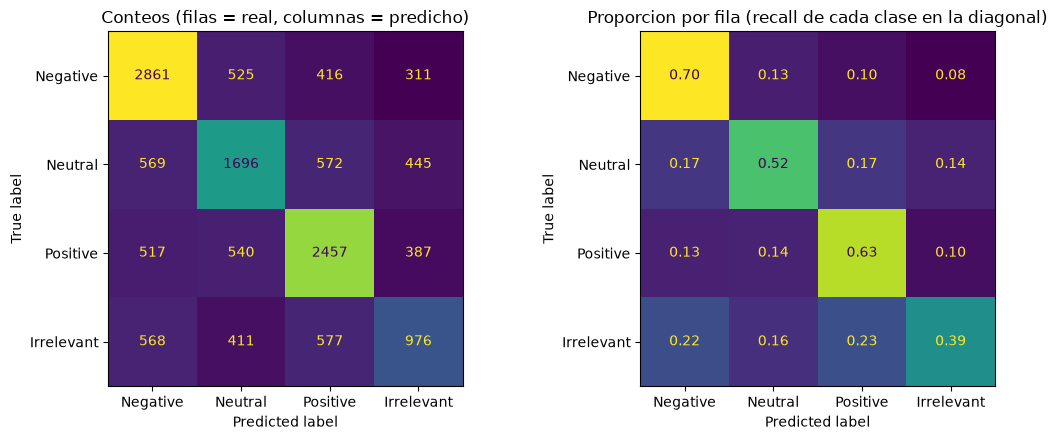

A que clase va a parar cada tweet Irrelevant:


,proporcion
pred,
Irrelevant,0.385
Positive,0.228
Negative,0.224
Neutral,0.162


F1 macro por entidad en test, de peor a mejor:


,tweets,f1_macro
entity,,
TomClancysGhostRecon,439,0.384
PlayStation5(PS5),387,0.386
PlayerUnknownsBattlegrounds(PUBG),451,0.390
CallOfDutyBlackopsColdWar,418,0.397
AssassinsCreed,403,0.408
TomClancysRainbowSix,431,0.427
RedDeadRedemption(RDR),390,0.445
FIFA,406,0.452
Google,407,0.458


In [16]:
sentiment_labels = ['Negative', 'Neutral', 'Positive', 'Irrelevant']
sentiment_pipeline = tweet_pipeline(sentiment_model()).fit(tweets_train['text'], tweets_train['sentiment'])
tweets_test['pred'] = sentiment_pipeline.predict(tweets_test['text'])

print(f'Vocabulario (uni+bigramas): {len(sentiment_pipeline.named_steps["tfidf"].vocabulary_)}')
print()
print('Reporte de clasificacion en test (ids nunca vistos):')
print(classification_report(tweets_test['sentiment'], tweets_test['pred'], labels=sentiment_labels, digits=3))

cm = confusion_matrix(tweets_test['sentiment'], tweets_test['pred'], labels=sentiment_labels)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay(cm, display_labels=sentiment_labels).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Conteos (filas = real, columnas = predicho)')
ConfusionMatrixDisplay(cm / cm.sum(axis=1, keepdims=True), display_labels=sentiment_labels).plot(ax=axes[1], colorbar=False, values_format='.2f')
axes[1].set_title('Proporcion por fila (recall de cada clase en la diagonal)')
plt.tight_layout()
plt.show()

irrelevant_rows = tweets_test[tweets_test['sentiment'] == 'Irrelevant']
print('A que clase va a parar cada tweet Irrelevant:')
display(irrelevant_rows['pred'].value_counts(normalize=True).round(3).to_frame('proporcion'))

entity_f1 = (tweets_test.groupby('entity')
             .apply(lambda d: pd.Series({'tweets': len(d), 'f1_macro': f1_score(d['sentiment'], d['pred'], average='macro')}), include_groups=False)
             .sort_values('f1_macro'))
entity_f1['tweets'] = entity_f1['tweets'].astype(int)
print('F1 macro por entidad en test, de peor a mejor:')
display(entity_f1.round(3))



El modelo está a menos de la mitad del camino entre el azar y un problema resuelto, y la clase que lo hunde es Irrelevant: menos de cuatro de cada diez se detectan, y las demás no se van a Neutral, como yo esperaba, sino a Negative y Positive.

Eso me cambia la idea de qué es Irrelevant. Yo la leía como "sin sentimiento", parecida a Neutral. Pero si el modelo le ve sentimiento, la hipótesis es otra: Irrelevant es un tweet que *sí* tiene carga emocional, solo que hacia otra cosa distinta de la entidad ("I love this book" en un tweet etiquetado bajo Amazon). Una bolsa de palabras ve "love" y vota Positive; no tiene manera de saber sobre quién recae. Si eso es cierto, dos cosas deberían verse: que los tweets Irrelevant mencionan menos a su entidad que los demás, y que en una muestra los errores tengan palabras de sentimiento apuntando a otro tema.



In [17]:
entity_key = (tweets['entity'].str.lower().str.replace(r'\(.*\)', '', regex=True)
              .str.replace(r'[^a-z0-9]', '', regex=True).str[:5])
tweets['mentions_entity'] = [key in text.lower().replace(' ', '') for key, text in zip(entity_key, tweets['text'])]

print('Proporcion de tweets cuyo texto menciona a su entidad (primeras 5 letras del nombre), por clase:')
display(tweets.groupby('sentiment')['mentions_entity'].mean().round(3).to_frame('menciona_entidad').loc[sentiment_labels])
print('Muestra de tweets Irrelevant en test:')
display(tweets_test[tweets_test['sentiment'] == 'Irrelevant'].sample(8, random_state=1)[['entity', 'pred', 'text']])


Proporcion de tweets cuyo texto menciona a su entidad (primeras 5 letras del nombre), por clase:


,menciona_entidad
sentiment,
Negative,0.528
Neutral,0.542
Positive,0.434
Irrelevant,0.329


Muestra de tweets Irrelevant en test:


,entity,pred,text
1263,Amazon,Positive,Everything about this book just sounds about SO GOOD..
11179,Facebook,Irrelevant,"Help me win this amazing competition from @ maxoak.fans. Instagram. @ maxoakDirect (Facebook), @ Maxoak _ fans (Twit..."
10747,Facebook,Positive,"The fun continues! Thank you so much for tuning in on Thursday!!! It was amazing!!. Join me tomorrow, with God's hel..."
8128,PlayerUnknownsBattlegrounds(PUBG),Negative,all u crazy gloating as how u r his fan n not a responsible journo. Sorry the u change fucking drummer never will. W...
8462,Verizon,Irrelevant,start off violent white people
3290,PlayStation5(PS5),Irrelevant,This is giving me @BudhaLovesBooty vibes .
4057,CS-GO,Irrelevant,The TOP 5 Highest Earning Players in CS:GO... . . . . . . . . . . . .
10154,CallOfDuty,Irrelevant,For I got trapped in a fucking van in Warzone! ( and things went slightly downhill rapidly from there... ).. Misadve...


Las dos cosas se ven. Los tweets Irrelevant nombran a su entidad bastante menos que las otras tres clases (la detección es tosca, cinco letras del nombre, así que la cifra absoluta no importa, la diferencia sí). Y en la muestra, "Everything about this book just sounds SO GOOD" cae en Positive, un tweet sobre un periodista cae en Negative: hay sentimiento, hacia otra cosa. Detectar Irrelevant exige saber *de qué* habla el tweet, y eso está fuera de lo que una bolsa de palabras puede representar. No es un fallo de este modelo en particular; es el límite de la representación, y lo declaro así en las conclusiones.

La tabla por entidad dice otra cosa que también va a las limitaciones: el rendimiento no es parejo. Entre la peor entidad y la mejor el F1 sube dos tercios, con cantidades de tweets de test parecidas, así que no es cuestión de muestra. No aíslo por qué unas entidades salen peor que otras; solo dejo constancia de que el 0.56 global esconde ese rango.

#### P4.2: ¿qué habría reportado si hubiera usado `validation.csv` como test?

Ya vi que los mil tweets de validación tienen su id en el train original. Ahora lo mido con el modelo entrenado: la métrica sobre validation.csv completo, y separada según si el id cayó en mi train o en mi test del split por id.




In [18]:
tweets_val = tweets_val_raw.copy()
tweets_val['pred'] = sentiment_pipeline.predict(tweets_val['text'])
tweets_val['id_en_mi_train'] = tweets_val['tweet_id'].isin(tweets_train['tweet_id'])

def macro_f1_block(df, name):
    return {'conjunto': name, 'tweets': len(df),
            'f1_macro': f1_score(df['sentiment'], df['pred'], average='macro'),
            'accuracy': (df['sentiment'] == df['pred']).mean()}

val_table = pd.DataFrame([
    macro_f1_block(tweets_val, 'validation.csv completo'),
    macro_f1_block(tweets_val[tweets_val['id_en_mi_train']], 'validation: ids que cayeron en mi train'),
    macro_f1_block(tweets_val[~tweets_val['id_en_mi_train']], 'validation: ids que cayeron en mi test'),
    macro_f1_block(tweets_test, 'mi test por id (referencia)'),
]).set_index('conjunto').round(3)
print('Mismo modelo sobre validation.csv, partido segun donde cayo cada id:')
display(val_table)


Mismo modelo sobre validation.csv, partido segun donde cayo cada id:


,tweets,f1_macro,accuracy
conjunto,,,
validation.csv completo,1000,0.905,0.906
validation: ids que cayeron en mi train,791,0.983,0.982
validation: ids que cayeron en mi test,209,0.602,0.617
mi test por id (referencia),13828,0.557,0.578


Con validation.csv como test yo habría reportado 0.90. Casi ochocientos de sus mil ids cayeron dentro de mi train y ahí el modelo acierta prácticamente todo: está reconociendo tweets que ya vio. Los doscientos y pico que cayeron en mi test dan bastante menos, aunque todavía por encima de mi test grande; es una muestra pequeña y no sé qué la distingue de mi test, así que no le saco más conclusión que esta: **el archivo de validación oficial no sirve para medir generalización con este dataset**, y cualquier cifra publicada sobre él hay que leerla con esa sospecha.

Cierro el caso de sentimiento. Lo que quedó medido: el split por id es lo único que da una métrica honesta, y esa métrica es modesta; la regresión logística sobre unigramas y bigramas gana por poco a los otros dos; Negative y Positive se detectan razonablemente, Neutral a medias, e Irrelevant mal, porque exige saber de qué habla el tweet y no solo qué palabras trae. El límite: todo esto es sobre tweets en inglés de 2020 sobre 32 entidades, mayormente videojuegos; un tweet sobre política o en español cae fuera de lo que el modelo vio.

---

## Parte 3: despliegue

Tengo dos pipelines de scikit-learn, cada uno con su vectorizador y su clasificador dentro, que reciben texto crudo y devuelven etiqueta y probabilidades. Desplegarlos tiene tres piezas: guardarlos en un formato que se pueda cargar sin volver a entrenar, documentarlos con una tarjeta de modelo, y publicarlos donde cualquiera pueda descargarlos. Uso `skops`, que es la librería con la que Hugging Face aloja modelos de scikit-learn: serializa el pipeline en un formato que no ejecuta código arbitrario al cargarlo (a diferencia de pickle) y genera la tarjeta de modelo que el Hub espera como `README.md`.

Antes de guardar, reentreno cada pipeline con todo su train más su test: la configuración ya está elegida y evaluada, y el modelo que se publica debería ver todos los datos disponibles. Las métricas de la tarjeta son las del test que ya reporté, no unas nuevas.





In [19]:
import skops.io as sio
from skops import card

repos = {
    'spam_sms': Path('models/spam_sms'),
    'tweet_sentiment': Path('models/tweet_sentiment'),
}
for repo_dir in repos.values():
    repo_dir.mkdir(parents=True, exist_ok=True)

spam_final = Pipeline([
    ('tfidf', TfidfVectorizer(lowercase=True, analyzer='char_wb', ngram_range=(2, 5), min_df=2, sublinear_tf=True)),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))
]).fit(spam['text'], spam['label'])

sentiment_final = tweet_pipeline(sentiment_model()).fit(tweets['text'], tweets['sentiment'])

sio.dump(spam_final, repos['spam_sms'] / 'model.skops')
sio.dump(sentiment_final, repos['tweet_sentiment'] / 'model.skops')

for name, pipe in [('spam_sms', spam_final), ('tweet_sentiment', sentiment_final)]:
    path = repos[name] / 'model.skops'
    untrusted = sio.get_untrusted_types(file=path)
    vocab_size = len(pipe.named_steps['tfidf'].vocabulary_)
    print(f'{path}: {path.stat().st_size / 1e6:.1f} MB, vocabulario de {vocab_size} terminos, tipos no confiables por defecto: {untrusted}')



models/spam_sms/model.skops: 23.4 MB, vocabulario de 37224 terminos, tipos no confiables por defecto: []


models/tweet_sentiment/model.skops: 109.5 MB, vocabulario de 166163 terminos, tipos no confiables por defecto: []


Los archivos pesan bastante para lo que son (un vector de pesos por término): skops guarda el vocabulario del vectorizador como JSON con un nodo por entrada, y el de tweets tiene más de 160 mil términos. Es el costo del formato seguro; para el Hub no es problema. Lo importante: `get_untrusted_types` devuelve vacío, o sea que los dos archivos se pueden cargar sin declarar confianza en ningún tipo extra.

La tarjeta de modelo va como `README.md` en cada carpeta y es lo que el Hub muestra en la página del modelo. Le pongo lo que alguien necesita para decidir si usarlo: qué es, con qué datos se entrenó, las métricas del test que ya reporté, el código para cargarlo, y las limitaciones que fueron saliendo en el cuaderno.


In [20]:
from huggingface_hub import ModelCardData

def build_card(pipe, description, metrics, limitations, training, dataset_url, repo_name):
    model_card = card.Card(pipe, model_format='skops')
    model_card.add(**{
        'Model description': description,
        'Model description/Intended uses & limitations': limitations,
        'Model description/Training Procedure': f'{training}\n\nDatos: {dataset_url}',
        'How to Get Started with the Model': (
            '```python\n'
            'import skops.io as sio\n'
            'from huggingface_hub import hf_hub_download\n'
            f'path = hf_hub_download(repo_id="<usuario>/{repo_name}", filename="model.skops")\n'
            'model = sio.load(path)\n'
            'model.predict(["texto de ejemplo"])\n'
            '```'
        ),
        'Model Card Authors': 'Jheison Martinez Bolivar',
        'Model Card Contact': 'jhmartinez07@unisalle.edu.co',
    })
    model_card.add_metrics(**metrics)
    model_card.delete('Citation')
    model_card.delete('Model description/Training Procedure/Model Plot')
    front_matter = ModelCardData(library_name='sklearn', license='mit', language='en',
                                 tags=['text-classification', 'sklearn', 'skops', 'tfidf']).to_yaml()
    return f'---\n{front_matter}\n---\n\n{model_card.render()}'

spam_metrics = comparison.loc['LogReg + TF-IDF caracteres'].to_dict()
spam_readme = build_card(
    spam_final,
    description=('Clasificador binario spam/ham para SMS en inglés: TF-IDF de n-gramas de caracteres (2 a 5, dentro de palabra) '
                 'y regresión logística con `class_weight="balanced"`. Devuelve la etiqueta y la probabilidad de spam.'),
    metrics={f'{k} (test, 20 % estratificado)': round(v, 3) for k, v in spam_metrics.items()},
    limitations=('Corpus de SMS en inglés de la década de 2000. Los errores residuales son spam escrito como conversación personal, '
                 'donde el tono pesa más que la URL o el número que a veces traen; el phishing moderno con tono oficial queda cerca del 50 %. '
                 'Umbral por defecto 0.5; la probabilidad se devuelve para que quien lo use juzgue los casos cercanos.'),
    training=('5158 mensajes únicos (4516 ham, 642 spam) tras reconstruir 50 filas partidas por comas y quitar duplicados exactos. '
              'Configuración elegida por validación cruzada estratificada de 5 pliegues sobre el 80 % de train, comparando '
              'MultinomialNB, LogisticRegression y LinearSVC sobre n-gramas de palabras y de caracteres. El modelo publicado se reentrenó con el 100 %.'),
    dataset_url='https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset',
    repo_name='spam-sms-tfidf-logreg',
)

sentiment_report = classification_report(tweets_test['sentiment'], tweets_test['pred'], labels=sentiment_labels, output_dict=True)
sentiment_metrics = {'f1_macro (test por id de tweet)': round(sentiment_report['macro avg']['f1-score'], 3),
                     'accuracy (test por id de tweet)': round(sentiment_report['accuracy'], 3)}
sentiment_metrics.update({f'f1 {label}': round(sentiment_report[label]['f1-score'], 3) for label in sentiment_labels})
sentiment_readme = build_card(
    sentiment_final,
    description=('Clasificador de sentimiento en 4 clases (Positive, Negative, Neutral, Irrelevant) para tweets en inglés: '
                 'TF-IDF de unigramas y bigramas de palabras y regresión logística con `class_weight="balanced"`. Devuelve la etiqueta y la probabilidad de cada clase.'),
    metrics=sentiment_metrics,
    limitations=(f'Las métricas son sobre tweets cuyo id no aparece en el entrenamiento; con un split aleatorio el F1 sube a {leak_table.loc["split aleatorio", "f1_macro"]:.3f} '
                 f'porque el dataset trae seis paráfrasis de cada tweet. Irrelevant se detecta mal (F1 {sentiment_report["Irrelevant"]["f1-score"]:.2f}): requiere saber de qué habla el tweet, '
                 'no solo qué palabras trae. Dominio: 32 entidades, sobre todo videojuegos, en 2020. No usa la entidad como entrada.'),
    training=('69354 filas del train original tras quitar 686 sin texto, textos con etiqueta contradictoria y duplicados exactos. '
              'Split 80/20 por id de tweet (GroupShuffleSplit), selección con GroupKFold de 5 pliegues comparando MultinomialNB, '
              'LogisticRegression y LinearSVC sobre unigramas, bigramas y caracteres. El modelo publicado se reentrenó con el 100 %.'),
    dataset_url='https://www.kaggle.com/datasets/jp797498e/twitter-entity-sentiment-analysis',
    repo_name='tweet-sentiment-tfidf-logreg',
)

(repos['spam_sms'] / 'README.md').write_text(spam_readme)
(repos['tweet_sentiment'] / 'README.md').write_text(sentiment_readme)

for repo_dir in repos.values():
    print(f'{repo_dir}: {sorted(p.name for p in repo_dir.iterdir())}')
print()
print(spam_readme[:1500])





models/spam_sms: ['README.md', 'model.skops']
models/tweet_sentiment: ['README.md', 'model.skops']

---
language: en
library_name: sklearn
license: mit
tags:
- text-classification
- sklearn
- skops
- tfidf
---


# Model description

Clasificador binario spam/ham para SMS en inglés: TF-IDF de n-gramas de caracteres (2 a 5, dentro de palabra) y regresión logística con `class_weight="balanced"`. Devuelve la etiqueta y la probabilidad de spam.

## Intended uses & limitations

Corpus de SMS en inglés de la década de 2000. Los errores residuales son spam escrito como conversación personal, donde el tono pesa más que la URL o el número que a veces traen; el phishing moderno con tono oficial queda cerca del 50 %. Umbral por defecto 0.5; la probabilidad se devuelve para que quien lo use juzgue los casos cercanos.

## Training Procedure

5158 mensajes únicos (4516 ham, 642 spam) tras reconstruir 50 filas partidas por comas y quitar duplicados exactos. Configuración elegida por validación cruzada

Antes de publicar, la prueba que importa: que lo que hay en disco sea utilizable sin nada de lo que está en memoria en este cuaderno. Cargo los dos `.skops` desde `models/` con `skops.io.load` y les paso mensajes escritos a mano. En una primera versión dos de los ejemplos resultaron ser mensajes del propio `spam.csv` apenas recortados, y el modelo reentrenado con el 100 % los "acertaba" de memoria; los cambié y ahora la primera tabla comprueba contra los tres archivos que ningún ejemplo aparece ni entero ni por sus primeras cinco palabras. Incluyo a propósito un tweet "difícil": sentimiento hacia una cosa y pregunta sobre otra, que es el patrón de Irrelevant, y un mensaje de phishing con tono oficial.


In [21]:
loaded = {name: sio.load(repo_dir / 'model.skops') for name, repo_dir in repos.items()}

spam_examples = [
    'Congratulations! Your mobile has won a holiday voucher worth £750. Text CLAIM to 81299 before midnight to collect.',
    'Running 10 min late, can you order me a coffee?',
    'Did you get the notes from class yesterday? I missed the last part.',
    'Your account has been locked. Verify at http://bit.ly/x9z within 24h',
]
sentiment_examples = [
    'This game is absolutely amazing, best purchase this year',
    'The servers are down again, I am done with this company',
    'New update drops next Tuesday according to the patch notes',
    'I love my new coffee machine, anyway what do you think about the Xbox?',
]

all_examples = spam_examples + sentiment_examples
known_texts = pd.concat([spam['text'], tweets['text'], tweets_val_raw['text'].dropna()]).str.lower()
overlap = pd.DataFrame({
    'ejemplo': [text[:60] for text in all_examples],
    'texto_identico_en_datos': [int((known_texts == text.lower()).sum()) for text in all_examples],
    'primeras_5_palabras_en_datos': [int(known_texts.str.contains(' '.join(text.lower().split()[:5]), regex=False).sum()) for text in all_examples],
}).set_index('ejemplo')
print('Comprobacion de que los ejemplos no vienen de los datasets:')
display(overlap)

def probability_table(model, texts):
    table = pd.DataFrame(model.predict_proba(texts), columns=model.classes_, index=texts).round(3)
    table['etiqueta'] = model.predict(texts)
    return table

print('Spam / ham con el modelo cargado desde disco:')
display(probability_table(loaded['spam_sms'], spam_examples))
print('Sentimiento con el modelo cargado desde disco:')
display(probability_table(loaded['tweet_sentiment'], sentiment_examples))

same_spam = (loaded['spam_sms'].predict(spam_examples) == spam_final.predict(spam_examples)).all()
same_sentiment = (loaded['tweet_sentiment'].predict(sentiment_examples) == sentiment_final.predict(sentiment_examples)).all()
print(f'Predicciones identicas entre el pipeline en memoria y el cargado desde disco: spam={same_spam}, sentimiento={same_sentiment}')


Comprobacion de que los ejemplos no vienen de los datasets:


,texto_identico_en_datos,primeras_5_palabras_en_datos
ejemplo,,
Congratulations! Your mobile has won a holiday voucher worth,0,0
"Running 10 min late, can you order me a coffee?",0,0
Did you get the notes from class yesterday? I missed the las,0,0
Your account has been locked. Verify at http://bit.ly/x9z wi,0,0
"This game is absolutely amazing, best purchase this year",0,0
"The servers are down again, I am done with this company",0,0
New update drops next Tuesday according to the patch notes,0,0
"I love my new coffee machine, anyway what do you think about",0,0


Spam / ham con el modelo cargado desde disco:


,ham,spam,etiqueta
Congratulations! Your mobile has won a holiday voucher worth £750. Text CLAIM to 81299 before midnight to collect.,0.079,0.921,spam
"Running 10 min late, can you order me a coffee?",0.738,0.262,ham
Did you get the notes from class yesterday? I missed the last part.,0.825,0.175,ham
Your account has been locked. Verify at http://bit.ly/x9z within 24h,0.504,0.496,ham


Sentimiento con el modelo cargado desde disco:


,Irrelevant,Negative,Neutral,Positive,etiqueta
"This game is absolutely amazing, best purchase this year",0.049,0.038,0.011,0.901,Positive
"The servers are down again, I am done with this company",0.013,0.932,0.019,0.036,Negative
New update drops next Tuesday according to the patch notes,0.053,0.551,0.232,0.164,Negative
"I love my new coffee machine, anyway what do you think about the Xbox?",0.200,0.086,0.036,0.679,Positive


Predicciones identicas entre el pipeline en memoria y el cargado desde disco: spam=True, sentimiento=True


Los archivos guardados cargan y predicen igual que los pipelines en memoria. Los mensajes claros salen bien, con probabilidades altas en spam y en los dos sentimientos marcados, y más justas en los ham cortos y coloquiales. Fallan tres, y cada uno dice algo distinto. El phishing ("account locked, verify at bit.ly") queda al 50/50: el corpus de spam es de SMS de hace más de una década, donde el spam grita ("WINNER!!", premios, números de tarificación especial), y el modelo no vio nunca un mensaje que imite a un banco con una URL corta y tono oficial. El tweet del "coffee machine" con pregunta sobre Xbox cae en Positive por la misma razón que vimos en test: hay sentimiento, hacia otra cosa. Y el peor de los tres es el aviso de parche ("New update drops next Tuesday according to the patch notes"), que es Neutral de manual y sale Negative con 0.59: no tiene la excusa de Irrelevant, simplemente el modelo no reconoce un tweet informativo sin carga, que es justo la clase donde el test ya daba recall a medias. Ninguno de los tres es un bug del despliegue; son los límites de los datos y de la representación, y por eso van abajo.

Los dos modelos quedaron publicados en el Hub con `publish.py`: [spam](https://huggingface.co/JheisonM/spam-sms-tfidf-logreg) y [sentimiento](https://huggingface.co/JheisonM/tweet-sentiment-tfidf-logreg). La prueba desde fuera, descargándolos del Hub como lo haría cualquier usuario, está en `prueba_despliegue.ipynb`.

---

## Cierre

### Respuestas

**P1.** El spam se distingue del ham antes de cualquier modelo: es más largo, se apila en el tope del SMS y casi siempre trae un número largo o una URL. Una regla con eso sola ya da F1 de 0.89 sin falsos positivos, y ese fue el listón para los modelos.

**P2.** Los tres clasificadores lineales le ganan a la regla una vez ajustados, y lo que más movió la métrica no fue el clasificador sino la representación: n-gramas de caracteres superan a cualquier configuración de palabras. Naive Bayes solo quedó atrás por combinarlo con TF-IDF y `alpha=1`; con conteos o con menos suavizado se pone a la par. El modelo final (regresión logística sobre caracteres 2-5, elegida sobre LinearSVC por dar probabilidades) da F1 de spam de 0.97 en test con siete errores en mil mensajes, casi todos spam escrito como conversación.

**P3.** Repartir las paráfrasis del mismo tweet entre train y test infla el F1 macro de 0.53 a 0.955. El `validation.csv` oficial tiene el mismo defecto: da 0.90 porque casi todos sus ids están en el train.

**P4.** Sobre tweets nunca vistos, la regresión logística con unigramas y bigramas es la mejor de las tres por poco. Si hay que dar un solo número, es el del test por id: F1 macro de 0.56 con `class_weight='balanced'` (en validación cruzada salió 0.535; el 0.53 de P3 era LinearSVC sin balancear sobre ese mismo test, no este modelo; y el del test es el único que no se usó para elegir nada). Negative y Positive se detectan razonablemente, Neutral a medias, e Irrelevant mal (F1 0.42). Los n-gramas de caracteres no ayudan aquí, y la entidad como token compraría dos centésimas que renuncio por no generalizar.

### Fortalezas

- **Las métricas son honestas.** En los dos casos el test no participó en ninguna decisión, el umbral se eligió fuera de él, y en tweets el split por id elimina la fuga que infla las cifras publicadas con este dataset.
- **Cada modelo le gana a una línea base que se muestra.** El de spam supera a una regla que ya era difícil de batir; el de sentimiento dobla al azar y cuadruplica a la clase mayoritaria.
- **Los errores están inspeccionados, no solo contados.** Se sabe qué spam se escapa y hacia dónde se va cada clase de sentimiento, y eso es lo que alimenta las mejoras de abajo.
- **El despliegue es reproducible y barato.** Dos pipelines completos (vectorizador + clasificador) en formato seguro, con tarjeta, cargables sin reentrenar, publicados en el Hub, y que devuelven probabilidades en vez de esconder la duda.

### Limitaciones

- **Dominio y época.** SMS en inglés de la década de 2000 y tweets de 2020 sobre 32 entidades, mayormente videojuegos. El phishing moderno queda al 50/50 y nada garantiza el comportamiento en español o en otros temas.
- **Irrelevant está fuera del alcance de una bolsa de palabras.** Detectarla exige saber de qué habla el tweet, no solo qué palabras trae; ningún ajuste de este pipeline lo va a resolver.
- **Ruido del dataset de tweets.** Las paráfrasis automáticas traen textos degenerados y etiquetas contradictorias; limpié lo que era medible, pero el generador dejó más ruido del que se ve a simple vista.
- **El umbral de spam es una decisión de producto, no del modelo.** Dejé 0.5 y expongo la probabilidad; quien despliegue para un usuario final tiene que decidir cuántos spam colados acepta a cambio de no perder mensajes legítimos.
- **Selección de modelo con un solo split.** La validación cruzada da desviaciones pequeñas entre pliegues, pero el test es uno solo por caso; otra semilla del split daría cifras algo distintas.
- **El rendimiento en sentimiento depende del tema.** El F1 por entidad va de 0.38 a 0.65; el 0.56 es un promedio que no describe a ninguna entidad en particular.

### Conclusiones

Lo que me llevo de esta actividad no es el número final sino dos cosas que cambiarían cómo empiezo la próxima. La primera: antes de comparar modelos hay que preguntarse cómo se parte el dato, porque en el caso de los tweets esa decisión pesó más que cualquier hiperparámetro y hace inservible la métrica que el propio dataset invita a reportar. La segunda: la representación manda. En spam, cambiar palabras por caracteres movió más el F1 que cambiar de clasificador, y en tweets el techo del 0.56 es del TF-IDF, no de la regresión logística.

De ahí salen las mejoras que sí tienen sentido. Para spam, un corpus actual con phishing y mensajes en español, y calibrar el umbral con el costo real de cada error. Para sentimiento, la única vía para Irrelevant es una representación que sepa sobre quién recae el sentimiento: un modelo preentrenado (un transformer ajustado para clasificación) que reciba el tweet y la entidad juntos, y medirlo con el mismo split por id para que la comparación con el 0.56 de aquí sea justa. El despliegue como está sirve para lo que sirve: dos modelos reproducibles, documentados con sus límites, y una interfaz que muestra la probabilidad en vez de esconder la duda detrás de una etiqueta.





